<a href="https://colab.research.google.com/github/CIA-Oceanix/FM_Tutorial_2026/blob/main/generative_models_2D_solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Flow Based Generative modeling
Author: Lucas Drumetz

This lab session is proposed to implement two flow based methods for generative models on simulated 2D datasets for which the ground truth density is known.

The main goal is to understand how to set up the methods and emphasize their differences in implementation, and requirements in terms of NN that need to be fit, loss functions, complexity, etc.


In [ ]:
# Imports and GPU set up

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader

# Set random seed for reproducibility
np.random.seed(42)


device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
# device = 'cpu'

# Assuming that we are on a CUDA machine, this should print a CUDA device:

print(device)

cuda:0


# Generate data sampled from the target distribution and its density

The target distribution is a mixture of two Gaussian distributions and of a "banana" shaped density in 2D. First we generate the data, then compute the corresponding density in closed form, with fixed values for their respective parameters (see code for details):

\begin{equation}
p_X = \alpha_1 \mathcal{N}(x;\mu_1,\Sigma_1) +  \alpha_2 \mathcal{N}(x;\mu_2,\Sigma_2) + \alpha_3 p_{banana}(x)
\end{equation}

where $p_{banana}$ uses the same formula as in the lecture slides, up to an offset, and $\alpha_1+\alpha_2+\alpha_3 = 1$

We first generate samples according to this distribution, plot them. Then we compute the closed form pdf and plot some of its contour lines.

In [ ]:

num_points = 5000  # Number of samples in total
# num_points =  10000 # Number of samples in total


# Here we fix the probabilitiess for a point to be sampled from each of the three components
# and sample the corresponding categorical distribution

categories = [0,1,2] # 0: left eye, 1: right eye, 2: smile
probabilities = [0.2, 0.2, 0.6]

draw = np.random.choice(categories, num_points, p=probabilities)
print(draw)
num_points_blobs = np.zeros(3).astype('int')
for i in range(3):
    num_points_blobs[i]= np.sum(draw == i)

print(num_points_blobs) # contains the results of this categorical sampling

# Parameters for the Gaussian distributions (eyes)

# Mean and covariance for the left eye
mean_left = np.array([-1.25, 2])
cov_left = 2*np.array([[0.1, 0], [0, 0.2]])

# Mean and covariance for the right eye
mean_right = np.array([1.25, 2])
cov_right = 2*np.array([[0.1, 0], [0, 0.2]])


# Generate points for the left and right eyes
left_eye = np.random.multivariate_normal(mean_left, cov_left, num_points_blobs[0])
right_eye = np.random.multivariate_normal(mean_right, cov_right, num_points_blobs[1])

# Parameters for the banana distribution (smile)

a = 0.5  # Parameter for the transformation
b = 4  # Shift down
z1 = np.random.randn(num_points_blobs[2])
z2 = np.random.randn(num_points_blobs[2])

# Apply transformation to get the banana shape
x1 = z1
x2 = z2 + a * z1**2 - b
smile = np.vstack((x1, x2)).T

# Combine all points
dataset = np.vstack((left_eye, right_eye, smile))

# Shuffle the dataset
np.random.shuffle(dataset)

# Visualize the dataset
plt.scatter(dataset[:, 0], dataset[:, 1], s=5)
plt.title("Smiley Face Dataset")
plt.xlabel("x1")
plt.ylabel("x2")
plt.close()

# Convert to PyTorch tensors
dataset_tensor = torch.tensor(dataset, dtype=torch.float32).to(device)

# Create a custom dataset for further use by Pytorch
class SmileyDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

# Create DataLoader
batch_size = 128
smiley_dataset = SmileyDataset(dataset_tensor.to(device))
data_loader = DataLoader(smiley_dataset, batch_size = batch_size, shuffle=True)

# Print some info
print("Dataset shape:", dataset.shape)
print("DataLoader created with batch size " + str(batch_size))

[1 2 2 ... 1 2 2]
[1029 1004 2967]
Dataset shape: (5000, 2)
DataLoader created with batch size 128


(-5.0, 5.0)

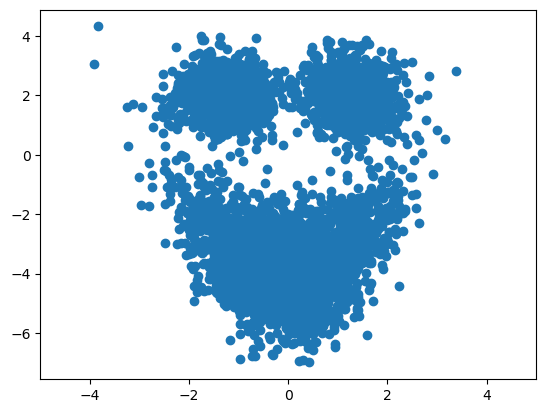

In [ ]:
plt.figure()
plt.scatter(smiley_dataset[:,0].cpu(),smiley_dataset[:,1].cpu())
plt.xlim(-5,5)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Define the PDF for the banana distribution (see exercise in the slides)
def banana_pdf(x1, x2, a, b):
    z1 = x1
    z2 = x2 - a * x1**2 + b
    return (1 / (2 * np.pi)) * np.exp(-(z1**2 + z2**2) / 2)

# Create a grid of points
x1_range = np.linspace(-3, 3, 100)
x2_range = np.linspace(-7, 4, 100)
X1, X2 = np.meshgrid(x1_range, x2_range)

# Compute the mixture density
mixture_density = np.zeros_like(X1)
for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
        # Left Gaussian
        f_left = multivariate_normal.pdf(np.array([X1[i, j], X2[i, j]]), mean=mean_left, cov=cov_left)
        # Right Gaussian
        f_right = multivariate_normal.pdf(np.array([X1[i, j], X2[i, j]]), mean=mean_right, cov=cov_right)
        # Banana distribution
        f_banana = banana_pdf(X1[i, j], X2[i, j], a, b)
        # Mixture density (weighted according to above defined probabilities)
        mixture_density[i, j] = (probabilities[0]*f_left + probabilities[1]*f_right + probabilities[2]*f_banana)


Text(0, 0.5, 'x2')

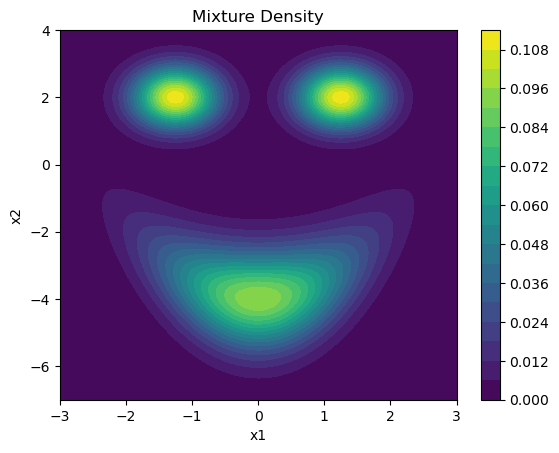

In [ ]:
# Plot the mixture density
plt.figure()
plt.contourf(X1, X2, mixture_density, levels=20, cmap='viridis')
plt.colorbar()
plt.title("Mixture Density")
plt.xlabel("x1")
plt.ylabel("x2")

# Continuous Normalizing Flows

First we define a continuous NF model to be trained via Maximum Likelihood. This requires parameterizing a vector field with a NN (a small MLP here), then defining the full model by numerically integrating the following ODE (backwards in time):

\begin{equation*}
\frac{d}{dt}
\begin{pmatrix}
z(t)\\s(t)   
\end{pmatrix} = \begin{pmatrix}
    g_\theta(z) \\
    -\textrm{tr}\left( J_{g_\theta}(z(t)) \right)
\end{pmatrix}
\end{equation*}

with final conditions $z(1) = x$, $x$ being a data point, and $s(1) = 0$. Once integrated, $z(0)$ contains the preimage of $x$ by the flow, and the corresponding log likelihood can be computed by:

\begin{equation*}
\log p(x) = \log p_0(z(0)) - s(0)
\end{equation*}

where $p_0 = \mathcal{N}(z;0,I)$.

## Set up Continuous Normalizing Flow model

The main difficulty from an implementation point of view is to compute the Jacobian of the model in a differentiable way. This requires creating a new computation graph at this step so as to be able to backpropagate through them.

For the ODE integration part, we could use a simple Euler method, but we prefer a much more accurate Runge-Kutta scheme (not much more expensive) that avoids numerical integration error and allows using far fewer steps (remember that we have to differentiate through this solver).


In [ ]:
import math
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
torch.manual_seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = 'cpu'

# Parameterize vector field with a simple MLP

class VectorField(nn.Module):
    def __init__(self, hidden_dim=64, alpha=0.01):
        super().__init__()
        self.alpha = alpha
        self.net = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 2),
        )
        # initialize last layer near zero
        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, t, y):
        return self.alpha * self.net(y) # we allow some parameter to scale down the output of the network to reduce the derivative values


# Define CNF model by integrating the vector field and the scalar equation on the log likelihood along trajectories

class CNF(nn.Module):
    """
    RK4 integrator for CNF in 2D.
    Uses exact vectorized divergence computed from per-stage f outputs.
    """

    def __init__(self, vector_field):
        super().__init__()
        self.vf = vector_field

# Code to compute the trace of the Jacobian of that model

    @staticmethod
    def divergence_from_f(y, f):
        """
        Compute divergence of f wrt y in 2D, given f = vf(y).
        y: (B,2) with requires_grad=True (or at least requires_grad in its history)
        f: (B,2) output computed from y
        returns (B,)
        """
        # ∂f0/∂y0
        df0_dy0 = torch.autograd.grad(f[:, 0].sum(), y, create_graph=True, retain_graph=True)[0][:, 0]
        # ∂f1/∂y1
        df1_dy1 = torch.autograd.grad(f[:, 1].sum(), y, create_graph=True)[0][:, 1]
        return df0_dy0 + df1_dy1

# This function computes an approximate z_t+1 from z_t, and s_t+1 from s_t, starting from initial conditions.
# This is using the Runge-Kutta method of order 4: not much more expensive than Euler but much more precise
# avoids too large discretization error and requires less integration steps.

    def integrate(self, y_init, z_init, t0=0.0, t1=1.0, num_steps=50):
        """
        Integrate forward from t0 -> t1 (works also for backward when h<0)
        returns y_final, z_final
        """
        h = (t1 - t0) / float(num_steps)
        y = y_init
        z = z_init

        for _ in range(num_steps):
            # Make a fresh leaf that requires grad for this integration step
            y0 = y.detach().requires_grad_(True)

            # stage 1
            k1 = self.vf(None, y0)                       # (B,2)
            tr1 = self.divergence_from_f(y0, k1)         # (B,)

            # stage 2
            y2 = y0 + 0.5 * h * k1                       # has requires_grad True because y0 does
            k2 = self.vf(None, y2)
            tr2 = self.divergence_from_f(y2, k2)

            # stage 3
            y3 = y0 + 0.5 * h * k2
            k3 = self.vf(None, y3)
            tr3 = self.divergence_from_f(y3, k3)

            # stage 4
            y4 = y0 + h * k3
            k4 = self.vf(None, y4)
            tr4 = self.divergence_from_f(y4, k4)

            # RK4 update for y
            y = y + (h / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)

            # RK4 update for z: dz/dt = -div(f) for forward integration
            z = z - (h / 6.0) * (tr1 + 2.0 * tr2 + 2.0 * tr3 + tr4).unsqueeze(1)

        return y, z

    def forward(self, y0, z0, t0=0.0, t1=1.0, num_steps=50):
        return self.integrate(y0, z0, t0, t1, num_steps=num_steps)

# The "true forward pass" of the model is actually a backwards integation

    def integrate_backward(self, y1, z1, t0=0.0, t1=1.0, num_steps=50):
        # integrate backward in time by swapping t0/t1 (integrating backwards is just changing the sign of the vector field)
        return self.integrate(y1, z1, t1, t0, num_steps=num_steps)


## Training Loop

The training loss is provided, except for the loss computation, which you have to implement from the ingredients of the model above.

In [ ]:
# Set up model and optimizer

vf = VectorField(hidden_dim=64, alpha=1).to(device)  # alpha small for stability
cnf = CNF(vf).to(device)
optimizer = optim.Adam(cnf.parameters(), lr=1e-4)


# Training loop (minimize negative log-likelihood of data y1)

num_epochs = 50
num_steps = 30  # integration steps; keep consistent between training/inference

losses = torch.zeros(num_epochs)

for i in range(num_epochs):
    epoch_loss = 0.0
    num_samples = 0
    for batch_idx, batch in enumerate(data_loader):

        y1_batch = batch.to(device)            # data at t=1
        B = y1_batch.size()[0]
        z1_batch = torch.zeros(B, 1, device=device)  # we generate a batch of initial conditions for the log likelihood.

        # integrate backwards to base distribution space (y0, z0)
        y0_pred, z0_pred = cnf.integrate_backward(y1_batch, z1_batch, num_steps=num_steps)

        # Compute the negative log-likelihood per sample in z0 space: 0.5*||y0||^2 + const + z0
        sq = 0.5 * torch.sum(y0_pred ** 2, dim=1)  # (B,)
        z0s = z0_pred.squeeze(1)                   # (B,)
        nll = sq + z0s

        loss = torch.mean(nll)

        optimizer.zero_grad()
        loss.backward()

        optimizer.step()
        epoch_loss += loss.item() * B
        num_samples += B

    avg_loss = epoch_loss / num_samples

    losses[i] = avg_loss

    print(f"Epoch {i:02d}/{num_epochs}  avg loss = {avg_loss:.6f}")



Epoch 00/50  avg loss = 5.479066
Epoch 01/50  avg loss = 5.040960
Epoch 02/50  avg loss = 4.425178
Epoch 03/50  avg loss = 3.802877
Epoch 04/50  avg loss = 3.273586
Epoch 05/50  avg loss = 2.861335
Epoch 06/50  avg loss = 2.553504
Epoch 07/50  avg loss = 2.337032
Epoch 08/50  avg loss = 2.191259
Epoch 09/50  avg loss = 2.096948
Epoch 10/50  avg loss = 2.040868
Epoch 11/50  avg loss = 2.010403
Epoch 12/50  avg loss = 1.997902
Epoch 13/50  avg loss = 1.997621
Epoch 14/50  avg loss = 2.001769
Epoch 15/50  avg loss = 2.007018
Epoch 16/50  avg loss = 2.014062
Epoch 17/50  avg loss = 2.018600
Epoch 18/50  avg loss = 2.018909
Epoch 19/50  avg loss = 2.021583
Epoch 20/50  avg loss = 2.014064
Epoch 21/50  avg loss = 2.010978
Epoch 22/50  avg loss = 2.002994
Epoch 23/50  avg loss = 1.995569
Epoch 24/50  avg loss = 1.984060
Epoch 25/50  avg loss = 1.973726
Epoch 26/50  avg loss = 1.965792
Epoch 27/50  avg loss = 1.954859
Epoch 28/50  avg loss = 1.946056
Epoch 29/50  avg loss = 1.938749
Epoch 30/5

Text(0, 0.5, 'total avg neg log likelihood')

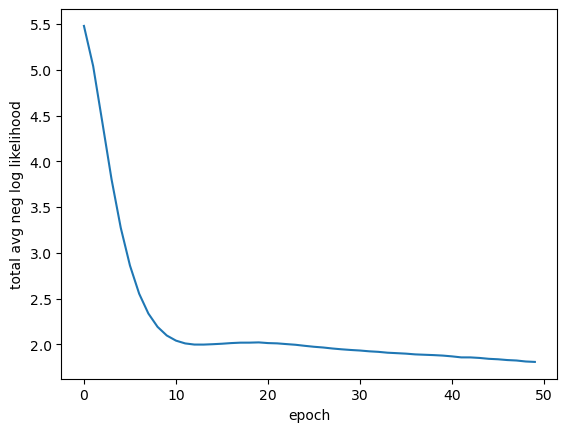

In [ ]:
plt.figure()
plt.plot(losses.detach().cpu())
plt.xlabel('epoch')
plt.ylabel('total avg neg log likelihood')

## Inference (generating new samples, and compute the associated likelihoods)

In [ ]:
# Code for inference (samples + likelihoods)

import math
import torch

def infer_y1(y0_batch, model, num_steps=200):

    device = next(model.parameters()).device
    y0 = y0_batch.to(device)
    B, D = y0.shape

    # base log-prob under standard normal
    log_base = -0.5 * torch.sum(y0 ** 2, dim=1) - 0.5 * D * math.log(2 * math.pi)
    z0 = log_base.unsqueeze(1).to(device)

    # Temporarily disable gradient tracking for parameters so no param grads are created.
    params = list(model.parameters())
    prev_requires = [p.requires_grad for p in params]
    for p in params:
        p.requires_grad_(False)

    try:
        # Enable grad for the forward so jacobian_trace (autograd.grad) works.
        with torch.enable_grad():
            y1_pred, z1_pred = model(y0, z0, num_steps=num_steps)
    finally:
        # Restore original requires_grad flags on params
        for p, req in zip(params, prev_requires):
            p.requires_grad_(req)

    # Detach and move to CPU for downstream use
    y1_pred = y1_pred.detach().cpu()
    logp_y1 = z1_pred.detach().squeeze(1).cpu()
    return y1_pred, logp_y1



<Figure size 640x480 with 0 Axes>

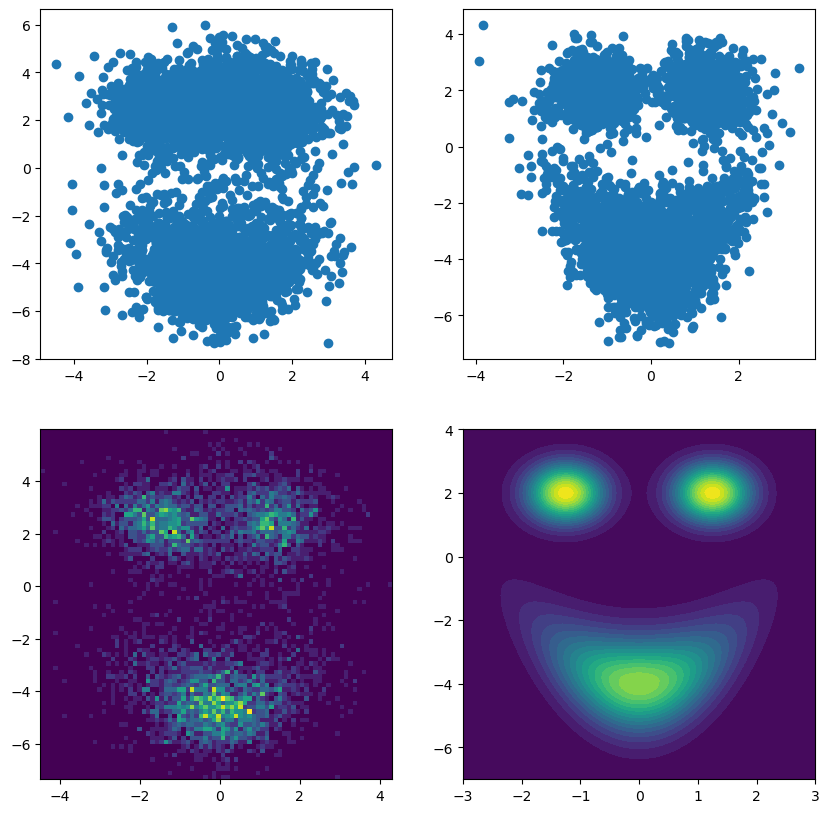

In [ ]:
# # Visualize samples: sample from base and push forward

num_generated_samples = 5000

y0 = torch.randn(num_generated_samples, 2)
y1_samps, logp = infer_y1(y0, cnf, num_steps=num_steps)

# scatter plots of generated samples vs GT, and 2D histogram vs GT density

plt.figure()
plt.figure(figsize = (10,10))
plt.subplot(221)
plt.scatter(y1_samps[:,0].numpy(), y1_samps[:,1].numpy())
plt.subplot(223)
plt.hist2d(y1_samps[:,0].numpy(), y1_samps[:,1].numpy(), bins=80)

plt.subplot(222)
plt.scatter(smiley_dataset[:,0].cpu(),smiley_dataset[:,1].cpu())
# plt.axis("equal")
# plt.xlim(-5,5)
plt.subplot(224)
plt.contourf(X1, X2, mixture_density, levels=20, cmap='viridis')


# Flow Matching

In this part, we implement a flow matching model. This is done in two steps. First we define a valid probability path between base and target through trajectories. Then we parameterize a time dependent neural network, before regressing this vector field against the direction of a trajectory to realize the conditional expectation:

\begin{equation*}
            \underset{\theta}{\textrm{arg min}} \  \mathbb{E}_{t\sim \mathcal{U}[0,1], (z_0,z_1)\sim p_0\otimes p_{data}}||v_t^\theta((1-t)z_1 + z_0) -  (z_1-z_0)||^2
\end{equation*}

Here the main difficulty is to set up an expressive network that includes time, not just the space variable. You will test two strategies for this: direct concatenation, and Random Fourier Features.

## Set up time-dependent MLP

In [ ]:

import math
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# small helper activation
def swish(x):
    return x * torch.sigmoid(x)


class SimpleTimeMLP(nn.Module):
    """
    Simple 2D -> 2D MLP with several ways to inject time information.

    Args:
      mode: 'concat' | 'fourier'
      hidden: hidden dim
      nlayers: number of hidden layers
      fourier_features: number of sin/cos pairs for Fourier time embed
    """
    def __init__(self, mode='concat', hidden=64, nlayers=2, fourier_features=4):
        super().__init__()
        assert mode in ('static', 'concat', 'fourier', 'film')
        self.mode = mode
        self.hidden = hidden
        self.nlayers = nlayers
        self.ff = fourier_features

        # compute input size
        if mode == 'concat':
            in_dim = 2 + 1
        elif mode == 'fourier':
            # for k frequencies we add 2*k features: sin and cos
            in_dim = 2 + 2 * self.ff
            # (optionally include raw t as well; omitted to keep simple)
        elif mode == 'static':
            in_dim = 2

        # base MLP layers
        layers = []
        layers.append(nn.Linear(in_dim, hidden))
        for _ in range(nlayers - 1):
            layers.append(nn.Linear(hidden, hidden))
        self.layers = nn.ModuleList(layers)

        # final output to 2D vector field
        self.out = nn.Linear(hidden, 2)


        # Fourier feature frequencies (fixed)
        if mode == 'fourier':
            # choose log-spaced frequencies: 2^0, 2^1, ... 2^(ff-1)
            freqs = (2.0 ** torch.arange(self.ff)).float() * torch.pi
            # freqs = (torch.arange(self.ff)).float() * torch.pi

            self.register_buffer('ff_freqs', freqs)  # non-parameter tensor

        # small init to keep outputs small initially (optional but helpful)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=0.8)
                nn.init.zeros_(m.bias)

    def time_embed_fourier(self, t):
        # t: (B,1) in [0,1] (recommended)
        # returns (B, 2*ff) -> [sin(omega t), cos(omega t), ...]
        # ff_freqs: (ff,)
        # ensure t shaped (B,1)
        if t.dim() == 1:
            t = t.unsqueeze(1)
        w = self.ff_freqs.unsqueeze(0)  # (1,ff)
        arg = t * w  # broadcast -> (B,ff)
        sin = torch.sin(arg)
        cos = torch.cos(arg)
        return torch.cat([sin, cos], dim=-1)  # (B, 2*ff)

    def forward(self, x, t):
        """
        x: (B,2)
        t: (B,) or (B,1) or scalar
        returns v: (B,2)
        """
        B = x.shape[0]

        # normalize t to (B,1) float tensor
        if torch.is_tensor(t):
            if t.dim() == 0:
                t = t.view(1, 1).expand(B, 1)
            elif t.dim() == 1:
                t = t.unsqueeze(1)
            elif t.dim() == 2 and t.shape[1] == 1:
                pass
            else:
                # if provided (B,...) try to reduce to scalar per batch
                t = t.reshape(B, 1)
        else:
            t = torch.tensor(float(t), device=x.device).view(1,1).expand(B,1)

        # prepare network input (for concat / fourier)
        if self.mode == 'concat':
            inp = torch.cat([x, t], dim=-1)  # (B,3)
            h = inp
        elif self.mode == 'fourier':
            tff = self.time_embed_fourier(t)  # (B, 2*ff)
            inp = torch.cat([x, tff], dim=-1)
            h = inp
        elif self.mode == 'static':
            h = x

        # pass through layers
        for i, lin in enumerate(self.layers):
            h = lin(h)
            # activation
            h = swish(h)

        v = self.out(h)
        return v

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TimePerLayerMLP(nn.Module):
    def __init__(self, hidden=64, nlayers=3, t_dim=16):
        super().__init__()
        self.nlayers = nlayers
        self.t_net = nn.Sequential(
            nn.Linear(1, 32),
            nn.ReLU(),
            nn.Linear(32, t_dim)
        )
        self.layers = nn.ModuleList()
        # first layer takes x only (2 -> hidden)
        self.layers.append(nn.Linear(2, hidden))
        # subsequent layers take hidden + t_dim
        for _ in range(nlayers - 1):
            self.layers.append(nn.Linear(hidden + t_dim, hidden))
        self.project = nn.Linear(hidden, hidden)  # keep dims stable if needed
        self.out = nn.Linear(hidden, 2)

        # initialize small biases/weights (optional)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=0.8)
                nn.init.zeros_(m.bias)

    def _prepare_inputs(self, x, t):
        """
        Ensure:
          - x is a float tensor on the model device with shape (B, 2)
          - t is a float tensor on the model device with shape (B, 1)
        Accepts scalar python floats, 0-D tensors, (B,) or (B,1) tensors, or single-sample x shaped (2,).
        """
        device = next(self.parameters()).device
        dtype = next(self.parameters()).dtype

        # --- x ---
        if not torch.is_tensor(x):
            x = torch.tensor(x, device=device, dtype=dtype)
        else:
            x = x.to(device=device, dtype=dtype)

        if x.dim() == 1:
            # single sample (D,) -> (1, D)
            x = x.unsqueeze(0)
        if x.dim() != 2:
            raise ValueError(f"Expected x to have 1 or 2 dims, got shape {x.shape}")

        # --- t ---
        if not torch.is_tensor(t):
            # python float / int
            t = torch.tensor(float(t), device=device, dtype=dtype)
        else:
            t = t.to(device=device, dtype=dtype)

        # flatten to 1D for counting
        t_flat = t.reshape(-1)
        B = x.shape[0]

        if t_flat.numel() == 1:
            # scalar -> expand to (B,1)
            t = t_flat.expand(B).unsqueeze(1)
        elif t_flat.numel() == B:
            # batch vector -> (B,1)
            t = t_flat.unsqueeze(1)
        else:
            # some other shape: try to broadcast or raise informative error
            try:
                # attempt to broadcast first element
                t = t_flat.unsqueeze(1).expand(B, 1)
            except Exception:
                raise ValueError(
                    f"Cannot interpret t with {t.shape}. "
                    f"Provide scalar, (B,), or (B,1) with B={B}."
                )

        return x, t

    def forward(self, x, t):
        # sanitize shapes / devices
        x, t = self._prepare_inputs(x, t)  # x: (B,2), t: (B,1)
        B = x.shape[0]

        # precompute embedding from t once
        t_e = self.t_net(t)  # (B, t_dim)

        # first layer: accepts x only
        h = self.layers[0](x)
        h = F.relu(h)

        # subsequent layers: concatenate t_e then reduce
        for i in range(1, self.nlayers):
            # concat t embedding
            h = torch.cat([h, t_e], dim=-1)      # (B, hidden + t_dim)
            h = self.layers[i](h)
            h = F.relu(h)

        # a small projection (keeps hidden size stable / optional)
        h = self.project(h)
        h = F.relu(h)

        out = self.out(h)    # (B,2)
        return out



## Define regression Loss

In [ ]:
# Define the loss function

def loss_fn(model, x,sigma):
    """The loss function for training flow matching generative models.

    Args:
    model: A PyTorch model instance that represents a
      time-dependent U-NET model.
    x: A mini-batch of training data.
    sigma: a small standard deviation value for the final distribution
    """
    t = torch.rand(x.shape[0], device=x.device) # generate batch of random t uniformly between 0 and 1
    t_broadcast = t.view(-1, 1)
    y = torch.randn_like(x) # generate batch of gaussian latents
    interp = (1-t_broadcast)*y + t_broadcast*x # linear interpolations defining the conditional paths
    interp_sto = sigma*torch.randn_like(x) + interp
    vt = model(interp_sto, t)
    loss = torch.mean(torch.sum((vt - (x-y))**2,dim = (1))) # regression loss
    return loss

## Training Loop

In [ ]:
# Set up model and optimizer

model_concat = SimpleTimeMLP(mode='concat', hidden=32, nlayers=2).to(device)
# model_fourier = SimpleTimeMLP(mode='fourier', hidden=32, nlayers=2, fourier_features=6).to(device)
# model_static = SimpleTimeMLP(mode='static', hidden=32, nlayers=2).to(device)
model_time_layer = TimePerLayerMLP(hidden=32, nlayers=2, t_dim=16).to(device)


# optimizer = optim.Adam(model_concat.parameters(), lr=1e-3)
# optimizer = optim.Adam(model_fourier.parameters(), lr=1e-3)
# optimizer = optim.Adam(model_static.parameters(), lr=1e-3)
optimizer = optim.Adam(model_time_layer.parameters(), lr=1e-3)
# Training loop (minimize negative log-likelihood of data y1)

num_epochs = 200
sigma = 1e-5

losses = torch.zeros(num_epochs)

for i in range(num_epochs):
    epoch_loss = 0.0
    num_samples = 0
    for batch_idx, batch in enumerate(data_loader):
        B = batch.shape[0]
        x = batch.to(device)
        # loss = loss_fn(model_concat, x, sigma)
        # loss = loss_fn(model_fourier, x, sigma)
        # loss = loss_fn(model_static, x, sigma)
        loss = loss_fn(model_time_layer, x, sigma)

        optimizer.zero_grad()
        loss.backward()

        optimizer.step()
        epoch_loss += loss.item() * B
        num_samples += B

    avg_loss = epoch_loss / num_samples

    losses[i] = avg_loss

    print(f"Epoch {i:02d}/{num_epochs}  avg loss = {avg_loss:.6f}")


Epoch 00/200  avg loss = 11.058375
Epoch 01/200  avg loss = 7.430711
Epoch 02/200  avg loss = 7.245949
Epoch 03/200  avg loss = 7.123989
Epoch 04/200  avg loss = 7.107892
Epoch 05/200  avg loss = 6.800420
Epoch 06/200  avg loss = 6.624625
Epoch 07/200  avg loss = 6.510631
Epoch 08/200  avg loss = 6.580242
Epoch 09/200  avg loss = 6.325212
Epoch 10/200  avg loss = 6.429809
Epoch 11/200  avg loss = 6.126092
Epoch 12/200  avg loss = 6.077230
Epoch 13/200  avg loss = 6.303702
Epoch 14/200  avg loss = 6.098643
Epoch 15/200  avg loss = 6.161407
Epoch 16/200  avg loss = 6.091508
Epoch 17/200  avg loss = 6.055651
Epoch 18/200  avg loss = 5.991810
Epoch 19/200  avg loss = 5.906152
Epoch 20/200  avg loss = 5.860784
Epoch 21/200  avg loss = 5.924245
Epoch 22/200  avg loss = 5.952431
Epoch 23/200  avg loss = 5.922863
Epoch 24/200  avg loss = 5.930212
Epoch 25/200  avg loss = 5.928969
Epoch 26/200  avg loss = 5.957121
Epoch 27/200  avg loss = 5.909172
Epoch 28/200  avg loss = 5.951617
Epoch 29/200 

Text(0, 0.5, 'total avg loss')

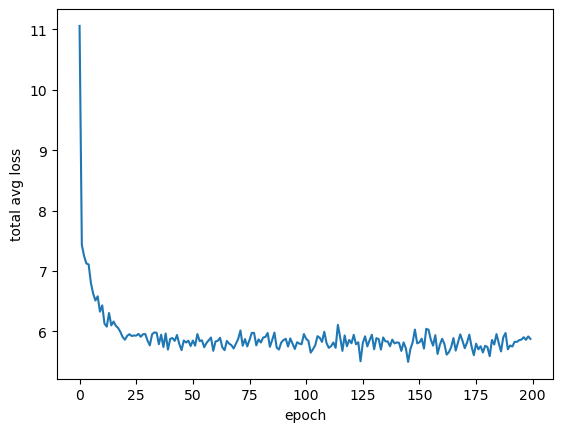

In [ ]:
plt.figure()
plt.plot(losses.detach().cpu())
plt.xlabel('epoch')
plt.ylabel('total avg loss')

## Inference (simply integrate the vector field)

In [ ]:
# generate samples (call an ODE solver from a latent sample with the vector field)

n_steps = 100
num_generated_samples = 10000

def RK4(x0, model, t0, t1, num_steps):
    """
    Classic RK4 integrator for dx/dt = v(x,t) where model(x,t) returns v.

    x0: (B,2) torch tensor (already on device or moved inside)
    model: callable model(x,t) -> (B,2)
    t0, t1: scalars (floats)
    num_steps: int
    """

    x = x0.to(device).float()

    h = float((t1 - t0) / float(num_steps))
    t = torch.tensor(float(t0), device=device)

    for _ in range(num_steps):
        k1 = model(x, t)                          # using current x
        k2 = model(x + 0.5 * h * k1, t + 0.5*h)
        k3 = model(x + 0.5 * h * k2, t + 0.5*h)
        k4 = model(x + h * k3, t + h)

        x = x + (h / 6.0) * (k1 + 2.0*k2 + 2.0*k3 + k4)

        t = t + h

    return x


with torch.no_grad():
    z = torch.randn(num_generated_samples,2) # generate gaussian latent
    samples = torch.clone(z).to(device)
    # samples = RK4(samples,model_fourier,0,1,n_steps)
    # samples = RK4(samples,model_concat,0,1,n_steps)
    # samples = RK4(samples,model_static,0,1,n_steps)
    samples = RK4(samples,model_time_layer,0,1,n_steps)


<Figure size 640x480 with 0 Axes>

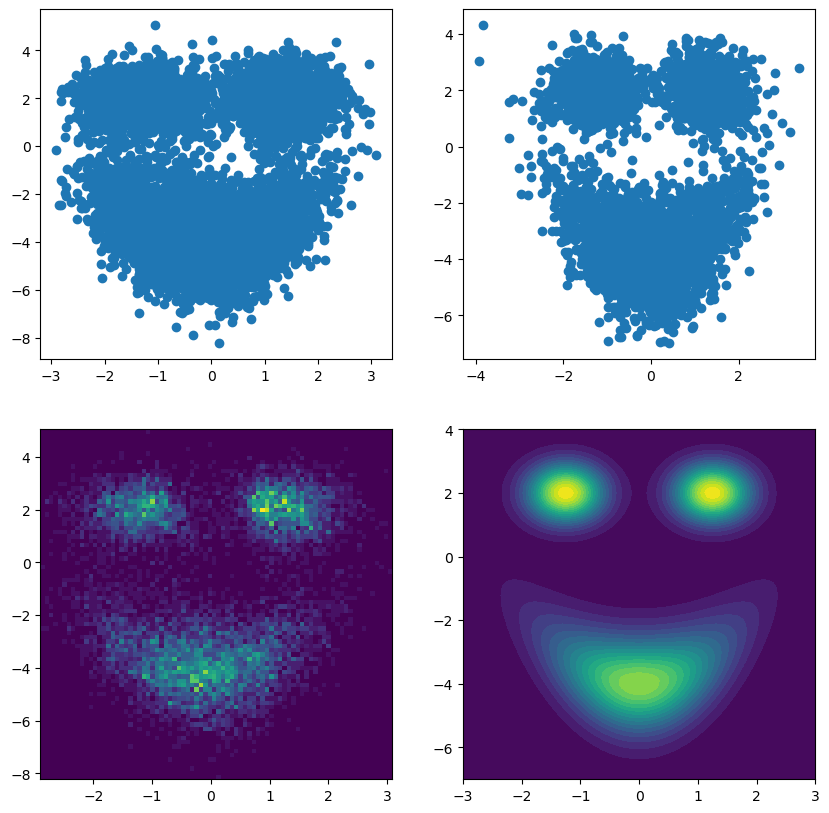

In [ ]:
# Visualize samples: sample from base and push forward
samples = samples.detach().cpu()

# scatter plots of generated samples vs GT, and 2D histogram vs GT density

plt.figure()
plt.figure(figsize = (10,10))
plt.subplot(221)
plt.scatter(samples[:,0].numpy(), samples[:,1].numpy())
plt.subplot(223)
plt.hist2d(samples[:,0].numpy(), samples[:,1].numpy(), bins=80)

plt.subplot(222)
plt.scatter(smiley_dataset[:,0].cpu(),smiley_dataset[:,1].cpu())
# plt.axis("equal")
# plt.xlim(-5,5)
plt.subplot(224)
plt.contourf(X1, X2, mixture_density, levels=20, cmap='viridis')


# Wrap up Question:
## Conclude on the differences between CNF and flow matching.

Compare them in terms of:

- Problem specification (type of loss)
- Neural Network parameterization
- Computational complexity
- Advantages/Drawbacks of each method.

## Generating Images: CIFAR-10 notebook

If you are done, you can switch to the notebook for CIFAR 10. The network is set up for you, you just have to recode the loss and training loop, just like here. It takes a while to train.